# Root Cause Analysis v3 — Drawdown Decomposition

**Dataset:** Dec 2014 – Mar 2026 (222,295 bars, 2,740 trades)  
**Baseline:** Win rate 44.7% | Sharpe 0.89 | Net P&L +$74,944 | Max Drawdown 17.5%

This notebook investigates *where* the 17.5% max drawdown is coming from across five dimensions:

| # | Dimension | Question |
|---|---|---|
| 1 | **Annual P&L** | Which years are loss years? |
| 2 | **Direction (LONG vs SHORT)** | Is one direction the primary drag? |
| 3 | **Entry Hour** | Are late-day entries hurting due to less runway? |
| 4 | **Day of Week** | Are Monday/Friday worse than mid-week? |
| 5 | **Losing Streak Depth** | Do a few deep streaks cause the drawdown, or many small ones? |

In [ ]:
import asyncio
asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

In [ ]:
import sys
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'xtick.color':      'white',
    'ytick.color':      'white',
    'text.color':       'white',
    'grid.color':       '#2a2a2a',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.5,
})

sys.path.insert(0, os.path.join(os.getcwd(), '..', '..'))

from data_fetch import fetch_data
from strategy  import run_backtest, INITIAL_EQUITY, SL_POINTS, TP_POINTS

## Load Data & Run Backtest

In [2]:
df = fetch_data(refresh=False)
print(f"Bars loaded : {len(df):,}")
print(f"Date range  : {df.index[0].strftime('%Y-%m-%d')} -> {df.index[-1].strftime('%Y-%m-%d')}")

trades, equity = run_backtest(df, trailing_stop_be=False)
print(f"Total trades: {len(trades):,}")

# Enrich with derived columns
trades['date']       = pd.to_datetime(trades['date'])
trades['year']       = trades['date'].dt.year
trades['month']      = trades['date'].dt.month
trades['dow']        = trades['date'].dt.dayofweek   # 0=Mon, 4=Fri
trades['dow_name']   = trades['date'].dt.day_name()
trades['entry_hour'] = pd.to_datetime(trades['entry_time']).dt.hour

trades[['date','direction','entry_hour','dow_name','exit_reason','pnl']].head()

[data_fetch] Loading cached data from data\NQ_5m.csv ...
[data_fetch] Loaded 3,700 rows (2026-01-12 -> 2026-03-23)
Bars loaded : 3,700
Date range  : 2026-01-12 -> 2026-03-23


Total trades: 46


,date,direction,entry_hour,dow_name,exit_reason,pnl
0,2026-01-12,LONG,11,Monday,EOD,470.0
1,2026-01-13,SHORT,10,Tuesday,TP,960.0
2,2026-01-14,SHORT,10,Wednesday,SL,-480.0
3,2026-01-15,SHORT,14,Thursday,TP,960.0
4,2026-01-16,SHORT,10,Friday,TP,960.0


---
## Section 1 — Annual P&L Breakdown

**Question:** Which years are loss years, and how much do they contribute to drawdown?

In [3]:
annual = trades.groupby('year').agg(
    trade_count=('pnl', 'count'),
    net_pnl=('pnl', 'sum'),
    win_rate=('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl=('pnl', 'mean'),
).reset_index()
annual['cum_equity'] = INITIAL_EQUITY + annual['net_pnl'].cumsum()

# Display table
display_df = annual.copy()
display_df['net_pnl']    = display_df['net_pnl'].apply(lambda x: f'${x:+,.0f}')
display_df['avg_pnl']    = display_df['avg_pnl'].apply(lambda x: f'${x:+,.0f}')
display_df['win_rate']   = display_df['win_rate'].apply(lambda x: f'{x:.1f}%')
display_df['cum_equity'] = display_df['cum_equity'].apply(lambda x: f'${x:,.0f}')
print(display_df.to_string(index=False))

 year  trade_count net_pnl win_rate avg_pnl cum_equity
 2026           46 $+9,290    54.3%   $+202    $59,290


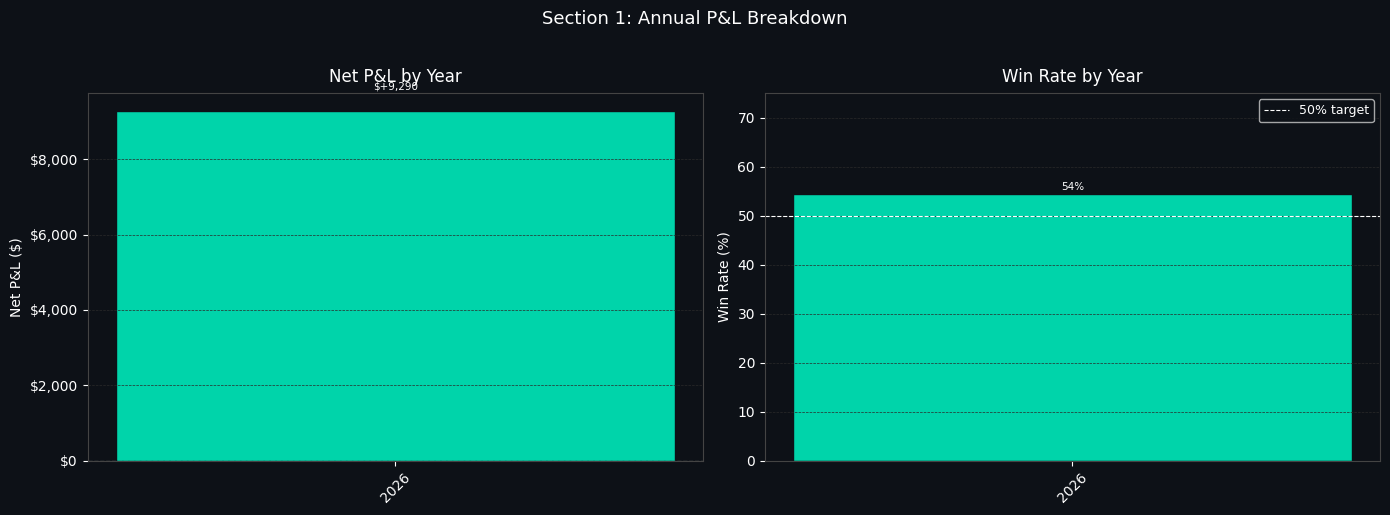

Loss years: []
Total loss from bad years: $+0


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Net P&L per year
ax = axes[0]
colors = ['#00d4aa' if v >= 0 else '#ff4444' for v in annual['net_pnl']]
bars = ax.bar(annual['year'], annual['net_pnl'], color=colors, edgecolor='#0d1117', width=0.7)
ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
for bar, val in zip(bars, annual['net_pnl']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (500 if val >= 0 else -1200),
            f'${val:+,.0f}', ha='center', va='bottom', fontsize=7.5, color='white')
ax.set_title('Net P&L by Year', fontsize=12, pad=8)
ax.set_ylabel('Net P&L ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.set_xticks(annual['year'])
ax.tick_params(axis='x', rotation=45)
ax.grid(True, axis='y')

# Right: Win rate per year with 50% target line
ax = axes[1]
bar_colors = ['#00d4aa' if v >= 50 else '#ff4444' for v in annual['win_rate']]
bars2 = ax.bar(annual['year'], annual['win_rate'], color=bar_colors, edgecolor='#0d1117', width=0.7)
ax.axhline(50, color='white', linewidth=0.8, linestyle='--', label='50% target')
for bar, val in zip(bars2, annual['win_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.0f}%', ha='center', va='bottom', fontsize=7.5, color='white')
ax.set_title('Win Rate by Year', fontsize=12, pad=8)
ax.set_ylabel('Win Rate (%)', fontsize=10)
ax.set_ylim(0, 75)
ax.set_xticks(annual['year'])
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)
ax.grid(True, axis='y')

plt.suptitle('Section 1: Annual P&L Breakdown', fontsize=13, y=1.02, color='white')
plt.tight_layout()
plt.show()

loss_years = annual[annual['net_pnl'] < 0]
print(f"Loss years: {loss_years['year'].tolist()}")
print(f"Total loss from bad years: ${loss_years['net_pnl'].sum():+,.0f}")

---
## Section 2 — LONG vs SHORT Direction Split

**Question:** Is one direction the primary source of losses and drawdown?

In [5]:
def dir_metrics(t):
    total  = len(t)
    wins   = (t['pnl'] > 0).sum()
    losses = (t['pnl'] <= 0).sum()
    # Max consecutive losses
    streak = max_consec = cur = 0
    for p in t['pnl']:
        if p <= 0:
            cur += 1
            max_consec = max(max_consec, cur)
        else:
            cur = 0
    return {
        'Trades':              total,
        'Wins':                wins,
        'Losses':              losses,
        'Win Rate':            f"{wins/total*100:.1f}%",
        'Avg P&L':             f"${t['pnl'].mean():+,.0f}",
        'Net P&L':             f"${t['pnl'].sum():+,.0f}",
        'Max Consec. Losses':  max_consec,
    }

longs  = trades[trades['direction'] == 'LONG']
shorts = trades[trades['direction'] == 'SHORT']

dir_df = pd.DataFrame({'LONG': dir_metrics(longs), 'SHORT': dir_metrics(shorts)})
print(dir_df.to_string())

                       LONG    SHORT
Trades                   24       22
Wins                     12       13
Losses                   12        9
Win Rate              50.0%    59.1%
Avg P&L               $+110    $+302
Net P&L             $+2,652  $+6,638
Max Consec. Losses        5        3


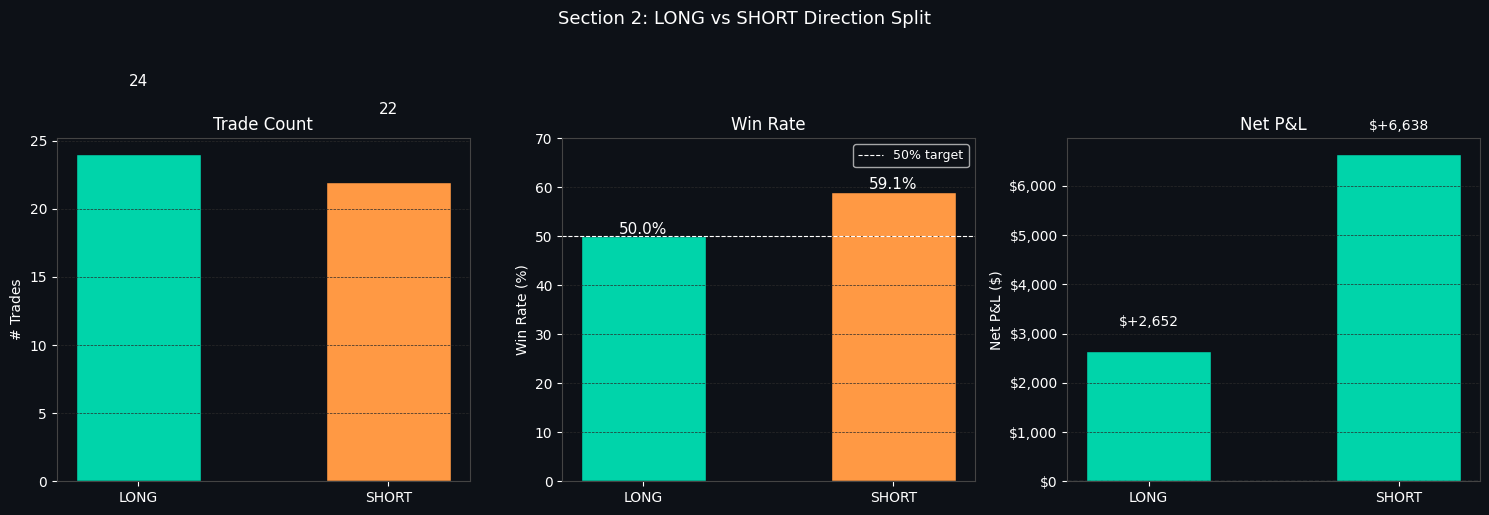

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dirs      = ['LONG', 'SHORT']
dir_data  = [longs, shorts]
dir_color = ['#00d4aa', '#ff9944']

# Trade count
ax = axes[0]
counts = [len(longs), len(shorts)]
bars = ax.bar(dirs, counts, color=dir_color, edgecolor='#0d1117', width=0.5)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontsize=11, color='white')
ax.set_title('Trade Count', fontsize=12)
ax.set_ylabel('# Trades', fontsize=10)
ax.grid(True, axis='y')

# Win rate
ax = axes[1]
wr = [(d['pnl'] > 0).mean() * 100 for d in dir_data]
bars2 = ax.bar(dirs, wr, color=dir_color, edgecolor='#0d1117', width=0.5)
ax.axhline(50, color='white', linewidth=0.8, linestyle='--', label='50% target')
for bar, val in zip(bars2, wr):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=11, color='white')
ax.set_title('Win Rate', fontsize=12)
ax.set_ylabel('Win Rate (%)', fontsize=10)
ax.set_ylim(0, 70)
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# Net P&L
ax = axes[2]
net = [d['pnl'].sum() for d in dir_data]
bar_col2 = ['#00d4aa' if v >= 0 else '#ff4444' for v in net]
bars3 = ax.bar(dirs, net, color=bar_col2, edgecolor='#0d1117', width=0.5)
ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
for bar, val in zip(bars3, net):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (500 if val >= 0 else -2000),
            f'${val:+,.0f}', ha='center', fontsize=10, color='white')
ax.set_title('Net P&L', fontsize=12)
ax.set_ylabel('Net P&L ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, axis='y')

plt.suptitle('Section 2: LONG vs SHORT Direction Split', fontsize=13, y=1.02, color='white')
plt.tight_layout()
plt.show()

---
## Section 3 — Entry Hour Analysis

**Question:** Are late-day entries (13:00+) hurting performance due to insufficient runway before the 15:45 force-exit?

In [7]:
hourly = trades.groupby('entry_hour').agg(
    count=('pnl', 'count'),
    win_rate=('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl=('pnl', 'mean'),
    net_pnl=('pnl', 'sum'),
    eod_exits=('exit_reason', lambda x: (x == 'EOD').sum()),
).reset_index()
hourly['eod_pct'] = hourly['eod_exits'] / hourly['count'] * 100

display_h = hourly.copy()
display_h['win_rate'] = display_h['win_rate'].apply(lambda x: f'{x:.1f}%')
display_h['avg_pnl']  = display_h['avg_pnl'].apply(lambda x: f'${x:+,.0f}')
display_h['net_pnl']  = display_h['net_pnl'].apply(lambda x: f'${x:+,.0f}')
display_h['eod_pct']  = display_h['eod_pct'].apply(lambda x: f'{x:.1f}%')
print(display_h.to_string(index=False))

 entry_hour  count win_rate avg_pnl net_pnl  eod_exits eod_pct
         10     38    47.4%   $+141 $+5,370          3    7.9%
         11      3   100.0%   $+498 $+1,494          2   66.7%
         13      2   100.0%   $+587 $+1,174          1   50.0%
         14      2   100.0%   $+647 $+1,294          1   50.0%
         15      1     0.0%    $-42    $-42          1  100.0%


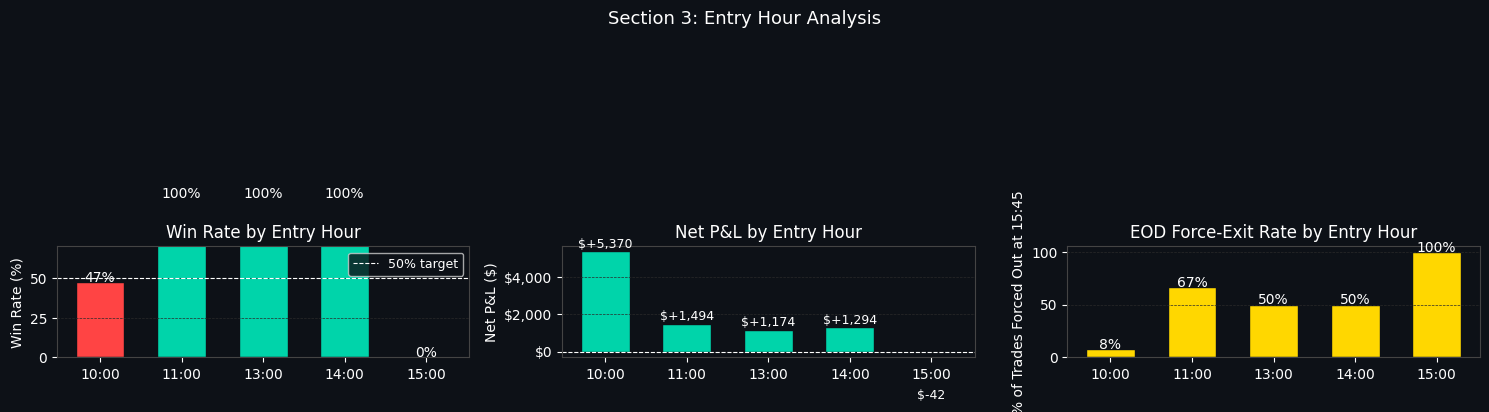

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
hours     = hourly['entry_hour'].astype(str) + ':00'

# Win rate by hour
ax = axes[0]
hr_colors = ['#00d4aa' if v >= 50 else '#ff4444' for v in hourly['win_rate']]
bars = ax.bar(hours, hourly['win_rate'], color=hr_colors, edgecolor='#0d1117', width=0.6)
ax.axhline(50, color='white', linewidth=0.8, linestyle='--', label='50% target')
for bar, val in zip(bars, hourly['win_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}%', ha='center', fontsize=10, color='white')
ax.set_title('Win Rate by Entry Hour', fontsize=12)
ax.set_ylabel('Win Rate (%)', fontsize=10)
ax.set_ylim(0, 70)
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# Net P&L by hour
ax = axes[1]
pnl_colors = ['#00d4aa' if v >= 0 else '#ff4444' for v in hourly['net_pnl']]
bars2 = ax.bar(hours, hourly['net_pnl'], color=pnl_colors, edgecolor='#0d1117', width=0.6)
ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
for bar, val in zip(bars2, hourly['net_pnl']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (200 if val >= 0 else -2500),
            f'${val:+,.0f}', ha='center', fontsize=9, color='white')
ax.set_title('Net P&L by Entry Hour', fontsize=12)
ax.set_ylabel('Net P&L ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, axis='y')

# EOD exit % by hour (proxy for truncated trades)
ax = axes[2]
ax.bar(hours, hourly['eod_pct'], color='#ffd700', edgecolor='#0d1117', width=0.6)
for i, (_, row) in enumerate(hourly.iterrows()):
    ax.text(i, row['eod_pct'] + 0.5, f"{row['eod_pct']:.0f}%",
            ha='center', fontsize=10, color='white')
ax.set_title('EOD Force-Exit Rate by Entry Hour', fontsize=12)
ax.set_ylabel('% of Trades Forced Out at 15:45', fontsize=10)
ax.grid(True, axis='y')

plt.suptitle('Section 3: Entry Hour Analysis', fontsize=13, y=1.02, color='white')
plt.tight_layout()
plt.show()

---
## Section 4 — Day of Week Analysis

**Question:** Are Monday (gap-open volatility) or Friday (end-of-week reversals) dragging performance?

In [9]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
dow = trades.groupby('dow_name').agg(
    count=('pnl', 'count'),
    win_rate=('pnl', lambda x: (x > 0).mean() * 100),
    avg_pnl=('pnl', 'mean'),
    net_pnl=('pnl', 'sum'),
).reindex(day_order).reset_index()

display_d = dow.copy()
display_d['win_rate'] = display_d['win_rate'].apply(lambda x: f'{x:.1f}%')
display_d['avg_pnl']  = display_d['avg_pnl'].apply(lambda x: f'${x:+,.0f}')
display_d['net_pnl']  = display_d['net_pnl'].apply(lambda x: f'${x:+,.0f}')
print(display_d.to_string(index=False))

 dow_name  count win_rate avg_pnl net_pnl
   Monday      9    55.6%   $+102   $+920
  Tuesday      9    66.7%   $+317 $+2,854
Wednesday     10    60.0%   $+220 $+2,198
 Thursday      9    44.4%   $+209 $+1,878
   Friday      9    44.4%   $+160 $+1,440


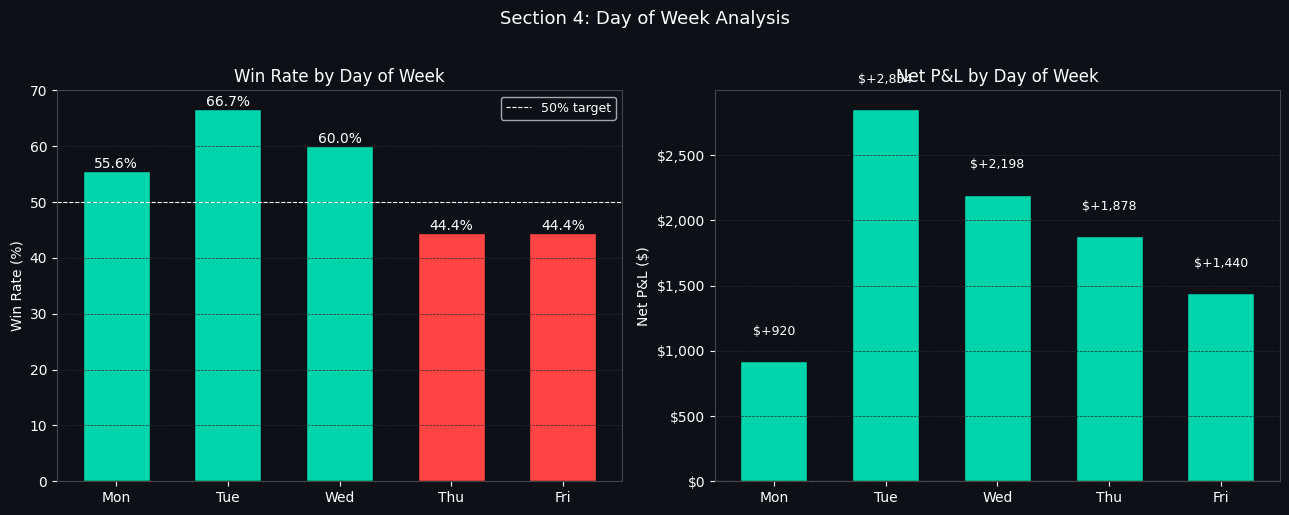

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
days_short = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri']

# Win rate by day
ax = axes[0]
wr_colors = ['#00d4aa' if v >= 50 else '#ff4444' for v in dow['win_rate']]
bars = ax.bar(days_short, dow['win_rate'], color=wr_colors, edgecolor='#0d1117', width=0.6)
ax.axhline(50, color='white', linewidth=0.8, linestyle='--', label='50% target')
for bar, val in zip(bars, dow['win_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10, color='white')
ax.set_title('Win Rate by Day of Week', fontsize=12)
ax.set_ylabel('Win Rate (%)', fontsize=10)
ax.set_ylim(0, 70)
ax.legend(fontsize=9)
ax.grid(True, axis='y')

# Net P&L by day
ax = axes[1]
pnl_colors2 = ['#00d4aa' if v >= 0 else '#ff4444' for v in dow['net_pnl']]
bars2 = ax.bar(days_short, dow['net_pnl'], color=pnl_colors2, edgecolor='#0d1117', width=0.6)
ax.axhline(0, color='white', linewidth=0.8, linestyle='--')
for bar, val in zip(bars2, dow['net_pnl']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (200 if val >= 0 else -2000),
            f'${val:+,.0f}', ha='center', fontsize=9, color='white')
ax.set_title('Net P&L by Day of Week', fontsize=12)
ax.set_ylabel('Net P&L ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, axis='y')

plt.suptitle('Section 4: Day of Week Analysis', fontsize=13, y=1.02, color='white')
plt.tight_layout()
plt.show()

---
## Section 5 — Losing Streak Analysis

**Question:** Does the drawdown come from a few deep losing streaks, or from widespread consistent losses?

In [11]:
# Identify all losing streaks
streaks = []
cur_len = 0
cur_loss = 0.0
streak_start_idx = None

for i, row in trades.iterrows():
    if row['pnl'] <= 0:
        if cur_len == 0:
            streak_start_idx = i
        cur_len  += 1
        cur_loss += row['pnl']
    else:
        if cur_len > 0:
            streaks.append({
                'start_idx':  streak_start_idx,
                'length':     cur_len,
                'total_loss': cur_loss,
                'start_date': trades.loc[streak_start_idx, 'date'],
            })
        cur_len  = 0
        cur_loss = 0.0

# Catch a streak at the end
if cur_len > 0:
    streaks.append({'start_idx': streak_start_idx, 'length': cur_len,
                    'total_loss': cur_loss, 'start_date': trades.loc[streak_start_idx, 'date']})

streaks_df = pd.DataFrame(streaks).sort_values('total_loss')

print(f"Total losing streaks   : {len(streaks_df)}")
print(f"Avg streak length      : {streaks_df['length'].mean():.1f} trades")
print(f"Max streak length      : {streaks_df['length'].max()} trades")
print(f"Worst single streak    : ${streaks_df['total_loss'].min():+,.0f}")
print()
print("Top 10 worst streaks:")
top10 = streaks_df.head(10)[['start_date', 'length', 'total_loss']].copy()
top10['total_loss'] = top10['total_loss'].apply(lambda x: f'${x:+,.0f}')
print(top10.to_string(index=False))

Total losing streaks   : 9
Avg streak length      : 2.3 trades
Max streak length      : 6 trades
Worst single streak    : $-2,880

Top 10 worst streaks:
start_date  length total_loss
2026-02-13       6    $-2,880
2026-02-27       3    $-1,440
2026-03-19       3    $-1,002
2026-03-05       2      $-960
2026-03-11       2      $-960
2026-02-04       2      $-960
2026-02-10       1      $-480
2026-01-14       1      $-480
2026-03-16       1      $-480


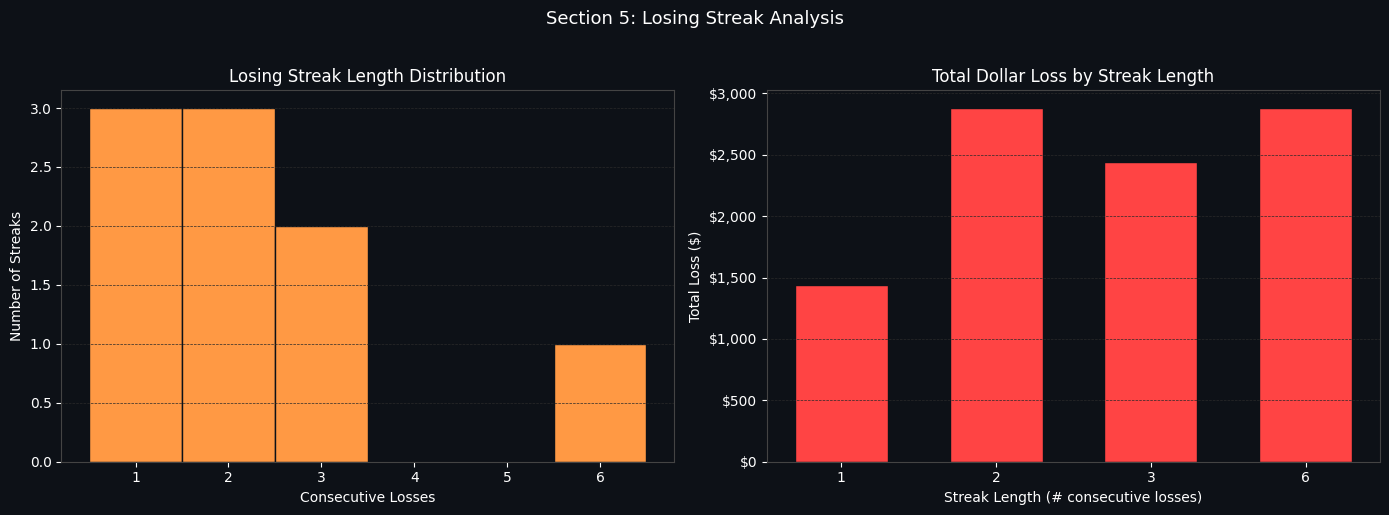

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Streak length distribution
ax = axes[0]
max_len = streaks_df['length'].max()
bins = range(1, max_len + 2)
ax.hist(streaks_df['length'], bins=bins, color='#ff9944', edgecolor='#0d1117', align='left')
ax.set_title('Losing Streak Length Distribution', fontsize=12)
ax.set_xlabel('Consecutive Losses', fontsize=10)
ax.set_ylabel('Number of Streaks', fontsize=10)
ax.set_xticks(range(1, max_len + 1))
ax.grid(True, axis='y')

# Cumulative loss contributed by streak length bucket
ax = axes[1]
bucket = streaks_df.groupby('length')['total_loss'].sum().abs()
ax.bar(bucket.index.astype(str), bucket.values, color='#ff4444', edgecolor='#0d1117', width=0.6)
ax.set_title('Total Dollar Loss by Streak Length', fontsize=12)
ax.set_xlabel('Streak Length (# consecutive losses)', fontsize=10)
ax.set_ylabel('Total Loss ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(True, axis='y')

plt.suptitle('Section 5: Losing Streak Analysis', fontsize=13, y=1.02, color='white')
plt.tight_layout()
plt.show()

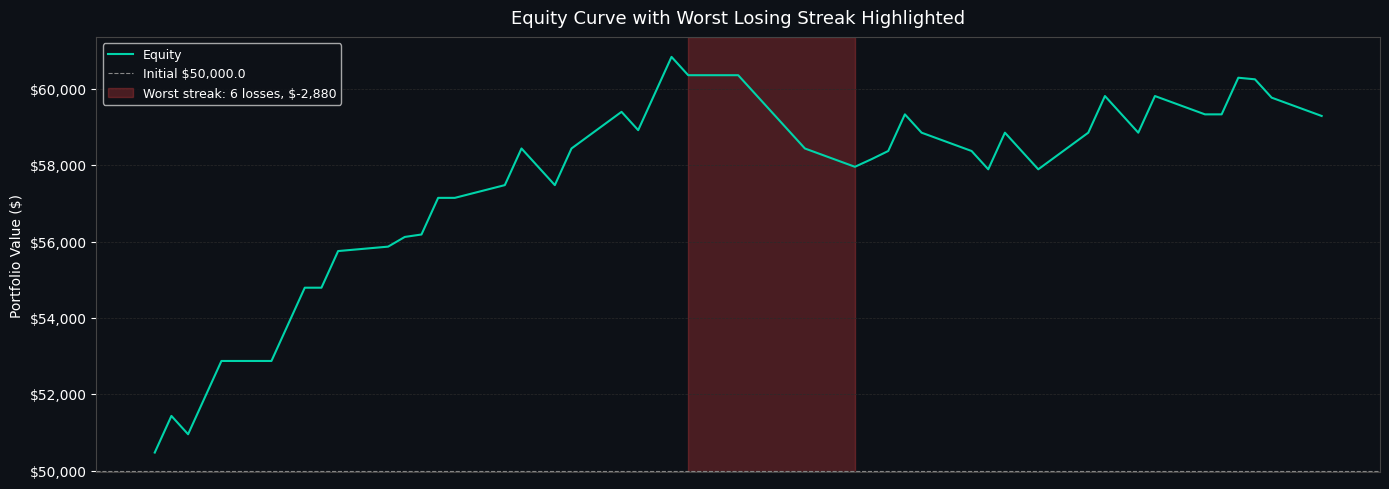

In [13]:
# Annotate worst streak on equity curve
worst = streaks_df.iloc[0]
worst_start = worst['start_date']
worst_end_idx = int(worst['start_idx']) + int(worst['length']) - 1
worst_end = trades.loc[worst_end_idx, 'date'] if worst_end_idx in trades.index else worst_start

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(equity.index, equity.values, color='#00d4aa', linewidth=1.5, label='Equity')
ax.axhline(INITIAL_EQUITY, color='#888', linewidth=0.8, linestyle='--', label=f'Initial ${INITIAL_EQUITY:,}')

# Shade worst streak window
ax.axvspan(worst_start, worst_end, color='#ff4444', alpha=0.25,
           label=f'Worst streak: {int(worst["length"])} losses, ${worst["total_loss"]:+,.0f}')

ax.set_title('Equity Curve with Worst Losing Streak Highlighted', fontsize=13, pad=10)
ax.set_ylabel('Portfolio Value ($)', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

---
## Summary & Conclusions

In [14]:
loss_years_list = annual[annual['net_pnl'] < 0]['year'].tolist()
loss_years_pnl  = annual[annual['net_pnl'] < 0]['net_pnl'].sum()

long_wr  = (longs['pnl'] > 0).mean() * 100
short_wr = (shorts['pnl'] > 0).mean() * 100
long_net = longs['pnl'].sum()
short_net= shorts['pnl'].sum()

best_hour  = hourly.loc[hourly['win_rate'].idxmax(), 'entry_hour']
worst_hour = hourly.loc[hourly['net_pnl'].idxmin(), 'entry_hour']

best_day  = dow.loc[dow['win_rate'].idxmax(), 'dow_name']
worst_day = dow.loc[dow['net_pnl'].idxmin(), 'dow_name']

print("=" * 65)
print(" RCA v3 — Drawdown Decomposition Summary")
print("=" * 65)
print()
print(f" #1  Annual P&L")
print(f"     Loss years        : {loss_years_list}")
print(f"     Total lost in bad years: ${loss_years_pnl:+,.0f}")
print()
print(f" #2  Direction")
print(f"     LONG  : {len(longs)} trades, {long_wr:.1f}% WR, ${long_net:+,.0f} net")
print(f"     SHORT : {len(shorts)} trades, {short_wr:.1f}% WR, ${short_net:+,.0f} net")
print()
print(f" #3  Entry Hour")
print(f"     Best hour  : {best_hour}:00")
print(f"     Worst hour : {worst_hour}:00 (most EOD exits = truncated runway)")
print()
print(f" #4  Day of Week")
print(f"     Best day   : {best_day}")
print(f"     Worst day  : {worst_day}")
print()
print(f" #5  Losing Streaks")
print(f"     Total streaks      : {len(streaks_df)}")
print(f"     Avg length         : {streaks_df['length'].mean():.1f} trades")
print(f"     Max length         : {streaks_df['length'].max()} trades")
print(f"     Worst streak       : ${streaks_df['total_loss'].min():+,.0f}")
print("=" * 65)

 RCA v3 — Drawdown Decomposition Summary

 #1  Annual P&L
     Loss years        : []
     Total lost in bad years: $+0

 #2  Direction
     LONG  : 24 trades, 50.0% WR, $+2,652 net
     SHORT : 22 trades, 59.1% WR, $+6,638 net

 #3  Entry Hour
     Best hour  : 11:00
     Worst hour : 15:00 (most EOD exits = truncated runway)

 #4  Day of Week
     Best day   : Tuesday
     Worst day  : Monday

 #5  Losing Streaks
     Total streaks      : 9
     Avg length         : 2.3 trades
     Max length         : 6 trades
     Worst streak       : $-2,880
